<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/outlier_detection_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [37]:
df=pd.read_csv('/content/titanic_data_updated.csv')

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
X=df.drop(columns=['Survived','PassengerId','Ticket','Name','Cabin'],axis=1)
y=df['Survived']

In [40]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,S
887,first,female,19.0,0,0,30.0000,S
888,third,female,NaN,1,2,23.4500,S
889,first,male,26.0,0,0,30.0000,C


In [41]:
y

,Survived
0,no
1,yes
2,yes
3,yes
4,no
...,...
886,no
887,yes
888,no
889,yes


In [42]:
X.describe()

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
def remove_outlier(X,y,num_features):
  X_clean=X.copy()
  y_clean=y.copy()

  for col in num_features:
    q1 = X_clean[col].quantile(.25)
    q3 = X_clean[col].quantile(.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (X_clean[col] < lower_bound) | (X_clean[col] > upper_bound)

    if mask.any():
      outlier_count=mask.sum()
      print(f"feature name::{col}|count:{outlier_count}")
      X_clean=X_clean[~mask]
      y_clean=y_clean[~mask]
    else:
      print(f"feature name:{col}| outlier not detected")

  return X_clean,y_clean

In [45]:
column_array=['Fare','Age','SibSp']

X_train_clean,y_train_clean=remove_outlier(X_train,y_train,column_array)

feature name::Fare|count:91
feature name::Age|count:7
feature name::SibSp|count:28


In [46]:
X_train.describe()

,Age,SibSp,Parch,Fare
count,575.000000,712.000000,712.000000,712.000000
mean,29.807687,0.492978,0.390449,31.819826
std,14.485211,1.060720,0.838134,48.059104
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,28.500000,0.000000,0.000000,14.454200
75%,39.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [47]:
X_train_clean.describe()

,Age,SibSp,Parch,Fare
count,464.000000,586.000000,586.000000,586.000000
mean,29.646552,0.269625,0.313993,17.200824
std,13.178854,0.498544,0.808317,13.654589
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,28.250000,0.000000,0.000000,11.370850
75%,38.000000,0.000000,0.000000,25.840625
max,65.000000,2.000000,6.000000,65.000000


<Axes: xlabel='Age', ylabel='Density'>

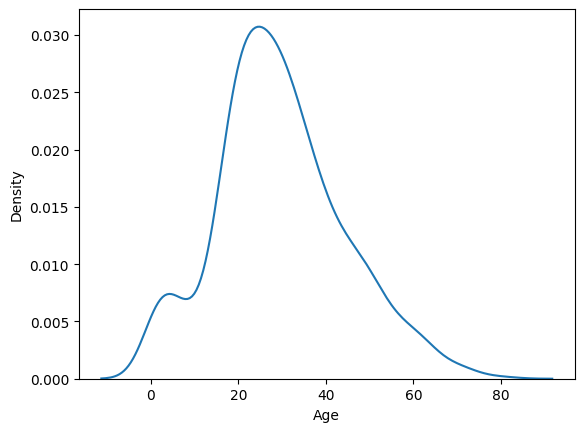

In [48]:
sns.kdeplot(data=df,x=df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

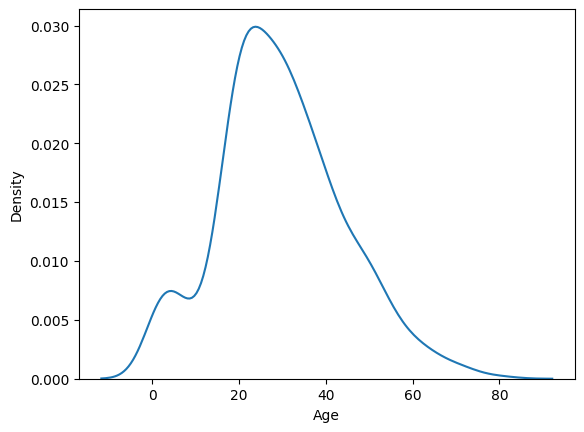

In [49]:
sns.kdeplot(data=X_train,x=X_train['Age'])

<Axes: xlabel='Age', ylabel='Density'>

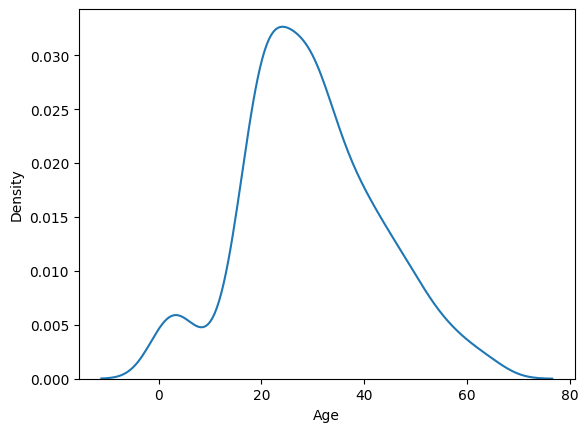

In [50]:
sns.kdeplot(data=X_train_clean,x=X_train_clean['Age'])

In [53]:
def remove_outlier_zscore(X,y,num_features):
  X_clean=X.copy()
  y_clean=y.copy()

  for col in num_features:
    mean=X_clean[col].mean()
    std=X_clean[col].std()

    if std==0:
      print('std 0')
      continue

    z_score=(X_clean[col]-mean)/std
    mask=abs(z_score)>3
    if mask.any():
      outlier_count=mask.sum()
      print(f"feature name::{col}|count:{outlier_count}")
      X_clean=X_clean[~mask]
      y_clean=y_clean[~mask]
    else:
      print(f"feature name:{col}| outlier not detected")

  return X_clean,y_clean

In [54]:
column_array=['Fare','Age','SibSp']

X_train_clean_z,y_train_clean_z=remove_outlier_zscore(X_train,y_train,column_array)

feature name::Fare|count:15
feature name::Age|count:2
feature name::SibSp|count:23


In [56]:
X_train_clean_z.describe()

,Age,SibSp,Parch,Fare
count,542.000000,672.000000,672.000000,672.000000
mean,30.271993,0.342262,0.334821,26.164694
std,13.893616,0.609512,0.800210,30.172218
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,29.000000,0.000000,0.000000,13.000000
75%,39.000000,1.000000,0.000000,27.787500
max,71.000000,3.000000,6.000000,164.866700


<Axes: xlabel='Fare', ylabel='Density'>

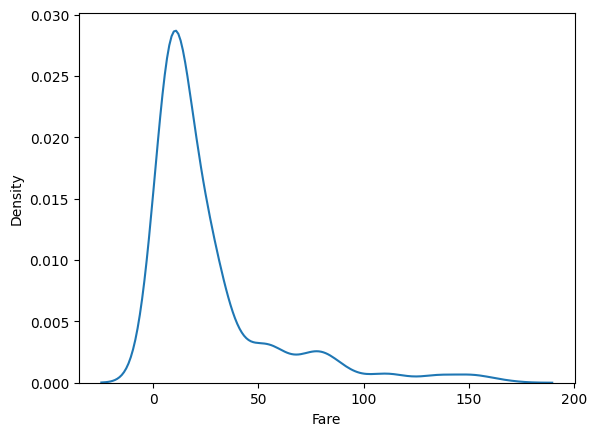

In [57]:
sns.kdeplot(data=X_train_clean_z,x=X_train_clean_z['Fare'])